# 第5回講義 演習
今回は，画像認識モデルの実装と学習を行います．

---
# Lecture 5: Exercise
This time, we will implement and learn an image recognition model.


## 目次

 [【課題】高度な画像認識の実装と学習](#scrollTo=tmK0SbsGDmAk)
1. [CIFAR-10データセットの読み込みと可視化](#scrollTo=Oqh8ZtFYDmAs)

1. [Preprocessing](#scrollTo=cguQMzK-DmBE)
  
    2.1. [Global Contrast Normalization (GCN)](#scrollTo=9ixCVk8_DmBK&line=1&uniqifier=1)
  
    2.2. [Zero-phase Component Analysis (ZCA) Whitening](#scrollTo=Po-FnL2YDmCb)

1. [Batch Normalization](#scrollTo=7NUaXp9tDmDC)

1. [Dropout](#scrollTo=t3KJgeiJWTJZ)

1. [畳み込みニューラルネットワーク(Convolutional Neural Networks)の実装と学習](#scrollTo=gVZ2C1uSDmDd)

    5.1. [各層クラスの実装](#scrollTo=ACf9-dGYDmDe)
  
    5.2. [ネットワークの構築&データローダーの定義](#scrollTo=xIU5IN4YDmFF)
  
    5.3. [学習](#scrollTo=YOS467vqDmFX&line=1&uniqifier=1)

1. [Activationの可視化](#scrollTo=cfAES-2gDmF4)
  
    6.1. [conv1](#scrollTo=zCse4fWgDmF-&line=1&uniqifier=1)
  
    6.2. [conv2](#scrollTo=pHrcKYUiDmGQ&line=1&uniqifier=1)
  
    6.3. [conv3](#scrollTo=EfsXVwmfDmGf&line=1&uniqifier=1)

1. [torch.nn に含まれるlayer, Loss関数の利用](#scrollTo=4Td7OG8MDmGw)
  
    7.1. [ネットワークの構築&データローダーの定義](#scrollTo=LReXSf-FDmGz&line=1&uniqifier=1)
  
    7.2. [学習](#scrollTo=WCfYomQMDmG_)

---
## table of contents

 [[Challenge] Implementation and learning of advanced image recognition](#scrollTo=tmK0SbsGDmAk)
1. [Loading and visualizing the CIFAR-10 dataset](#scrollTo=Oqh8ZtFYDmAs)

1. [Preprocessing](#scrollTo=cguQMzK-DmBE)
  
    2.1. [Global Contrast Normalization (GCN)](#scrollTo=9ixCVk8_DmBK&line=1&uniqifier=1)
  
    2.2. [Zero-phase Component Analysis (ZCA) Whitening](#scrollTo=Po-FnL2YDmCb)

1. [Batch Normalization](#scrollTo=7NUaXp9tDmDC)

1. [Dropout](#scrollTo=t3KJgeiJWTJZ)

1. [Implementation and training of Convolutional Neural Networks](#scrollTo=gVZ2C1uSDmDd)

    5.1. [Implementation of each layer class](#scrollTo=ACf9-dGYDmDe)
  
    5.2. [Build network & define data loader](#scrollTo=xIU5IN4YDmFF)
  
    5.3. [study](#scrollTo=YOS467vqDmFX&line=1&uniqifier=1)

1. [Activation visualization](#scrollTo=cfAES-2gDmF4)
  
    6.1. [conv1](#scrollTo=zCse4fWgDmF-&line=1&uniqifier=1)
  
    6.2. [conv2](#scrollTo=pHrcKYUiDmGQ&line=1&uniqifier=1)
  
    6.3. [conv3](#scrollTo=EfsXVwmfDmGf&line=1&uniqifier=1)

1. [Use layer and Loss functions included in torch.nn](#scrollTo=4Td7OG8MDmGw)
  
    7.1. [Build network & define data loader](#scrollTo=LReXSf-FDmGz&line=1&uniqifier=1)
  
    7.2. [study](#scrollTo=WCfYomQMDmG_)


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torch.nn.functional as F
from torchvision import datasets, transforms, models


import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

rng = np.random.RandomState(1234)
random_state = 42


## 【課題】高度な画像認識の実装と学習

---
## [Challenge] Implementation and learning of advanced image recognition


## 1.CIFAR-10データセットの読み込みと可視化

---
## 1. Loading and visualizing the CIFAR-10 dataset


[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)は10種類の「物体カラー写真」（乗り物や動物など）の画像データセットであり，PytorchやTensorflowなど各ライブラリからダウンロードすることが可能です．

---
[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) is an image dataset of 10 types of "object color photographs" (vehicles, animals, etc.) and can be downloaded from various libraries such as Pytorch and Tensorflow.


In [2]:
batch_size = 1  # Set to 1 for ease of visualization.

# Loading data
# transforms.ToTensr: Converts input data (such as np.ndarray) to a PyTorch tensor. When handling images with PyTorch, be careful because (batch size, number of channels, height, width)
dataloader_train = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data/cifar10', train=True, download=True, transform=transforms.ToTensor()),
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


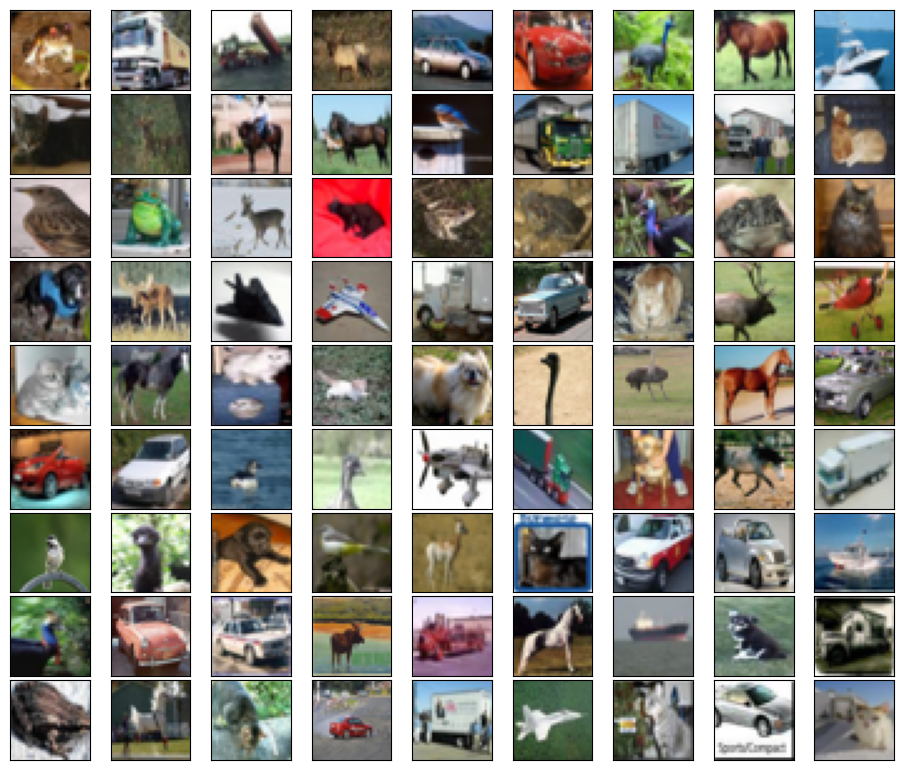

In [3]:
fig = plt.figure(figsize=(9, 15))
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.5, hspace=0.05,
                    wspace=0.05)

# Visualize dataset images
i = 0
for x, _ in dataloader_train:
    x = np.transpose(torch.squeeze(x).numpy(), (1, 2, 0))
    ax = fig.add_subplot(9, 9, i + 1, xticks=[], yticks=[])
    ax.imshow(x)
    i += 1
    if i >= 81:
        break

## 2.Preprocessing

- Global Contrast Normalization (GCN)
- ZCA Whitening

### 2.1. Global Contrast Normalization (GCN)

$$ {\bf x}^{GCN} = \frac{{\bf x} - \bar{{\bf x}}}{\sqrt{\sigma_{{\bf x}}^2 + \epsilon }} $$

- 通常の標準化とは違い，画像ごとに行います．
- 可視化した際は（可視化に際してスケールを[0,1]化しているので）見た目に変化はありません．

---
- Unlike normal standardization, this is done for each image.
- When visualized, there is no change in appearance (because the scale is set to [0,1] during visualization).


In [4]:
# There is no existing GCN class, so create it yourself
class gcn():
    def __init__(self):
        pass

    def __call__(self, x):
        mean = torch.mean(x)
        std = torch.std(x)
        return (x - mean)/(std + 10**(-6))  # Prevent division by 0


# Normalize the image after standardization to [0, 1]
def deprocess(x):
    """
    Argument
    --------
    x : np.ndarray
        input image．(H, W, C)

    Return
    ------
    _x : np.ndarray
        Image normalized to [0, 1]．(H, W, C)
    """
    _min = np.min(x)
    _max = np.max(x)
    _x = (x - _min)/(_max - _min)
    return _x

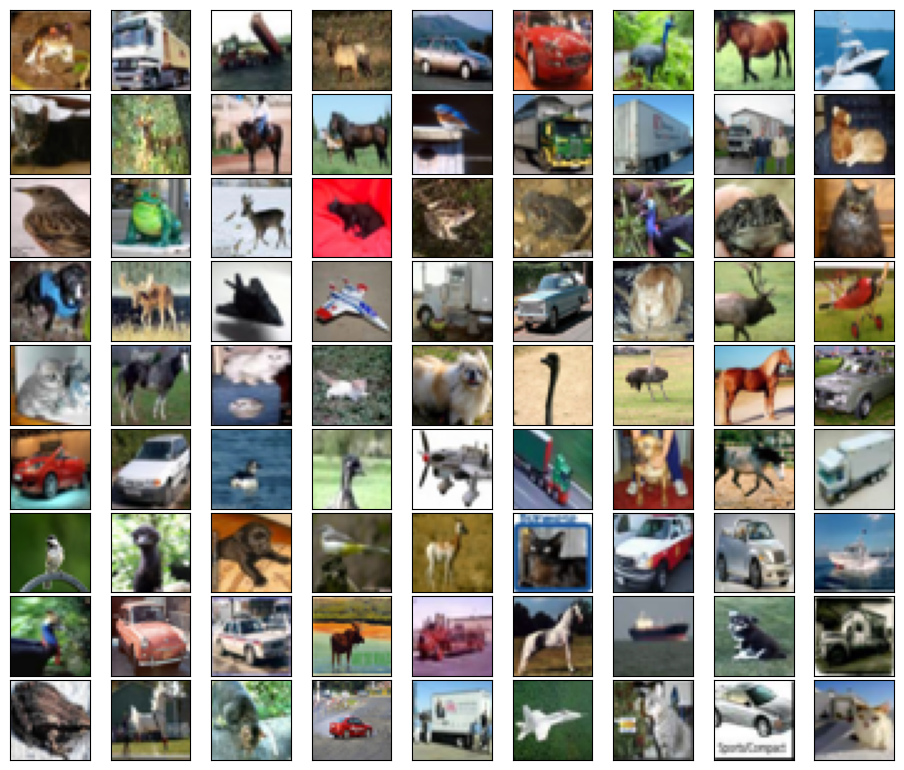

In [5]:
GCN = gcn()
# transforms.Compose: Summarize the processing performed in data preprocessing in order
transform_GCN = transforms.Compose([transforms.ToTensor(),
                                    GCN])  # Perform GCN processing after converting to PyTorch Tensor type

dataloader_train_gcn = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data/cifar10', train=True, transform=transform_GCN),
    batch_size=batch_size,
    shuffle=False
)

fig = plt.figure(figsize=(9, 15))
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.5, hspace=0.05,
                    wspace=0.05)

i = 0
for x, _ in dataloader_train_gcn:
    x = np.transpose(torch.squeeze(x).numpy(), (1, 2, 0))
    ax = fig.add_subplot(9, 9, i + 1, xticks=[], yticks=[])
    ax.imshow(deprocess(x))
    i += 1
    if i >= 81:
        break

### 2.2. Zero-phase Component Analysis (ZCA) Whitening

$$ {\bf x}^{ZCA} = A(\Lambda + \epsilon I)^{-\frac{1}{2}} A^{\mathrm{T}} ({\bf x} - \bar{\bf x}) $$

- torch.linalg.eigh(対称行列用の固有値分解)を用いてZCAを実装しています．

---
- ZCA is implemented using torch.linalg.eigh (eigenvalue decomposition for symmetric matrices).


In [6]:
# Implementing ZCA whitening
class ZCAWhitening():
    def __init__(self, epsilon=1e-4, device="cuda"):  # GPU is used because the calculation is heavy
        self.epsilon = epsilon
        self.device = device

    def fit(self, images):  # Compute transformation matrix and mean from data
        """
        Argument
        --------
        images : torchvision.datasets.cifar.CIFAR10
            input image（Entire training data）．(N, C, H, W)
        """
        x = images[0][0].reshape(1, -1)  # Converting an image (1 piece) to 1D
        self.mean = torch.zeros([1, x.size()[1]]).to(self.device)  # A tensor that stores the average value. Same shape as x
        con_matrix = torch.zeros([x.size()[1], x.size()[1]]).to(self.device)
        for i in range(len(images)):  # Take the average for each data
            x = images[i][0].reshape(1, -1).to(self.device)
            self.mean += x / len(images)
            con_matrix += torch.mm(x.t(), x) / len(images)
            if i % 10000 == 0:
                print("{0}/{1}".format(i, len(images)))
        con_matrix -= torch.mm(self.mean.t(), self.mean)
        # E: Eigenvalue V: Arrangement of eigenvectors
        E, V = torch.linalg.eigh(con_matrix)  # Eigenvalue decomposition
        self.ZCA_matrix = torch.mm(torch.mm(V, torch.diag((E.squeeze()+self.epsilon)**(-0.5))), V.t())  # A(\Lambda + \epsilon I)^{1/2}A^T
        print("completed!")

    def __call__(self, x):
        size = x.size()
        x = x.reshape(1, -1).to(self.device)
        x -= self.mean  # x - \bar{x}
        x = torch.mm(x, self.ZCA_matrix.t())
        x = x.reshape(tuple(size))
        x = x.to("cpu")
        return x

In [7]:
zca = ZCAWhitening()
images = datasets.CIFAR10('./data/cifar10', train=True, transform=transforms.ToTensor())
zca.fit(images)

0/50000
10000/50000
20000/50000
30000/50000
40000/50000
completed!


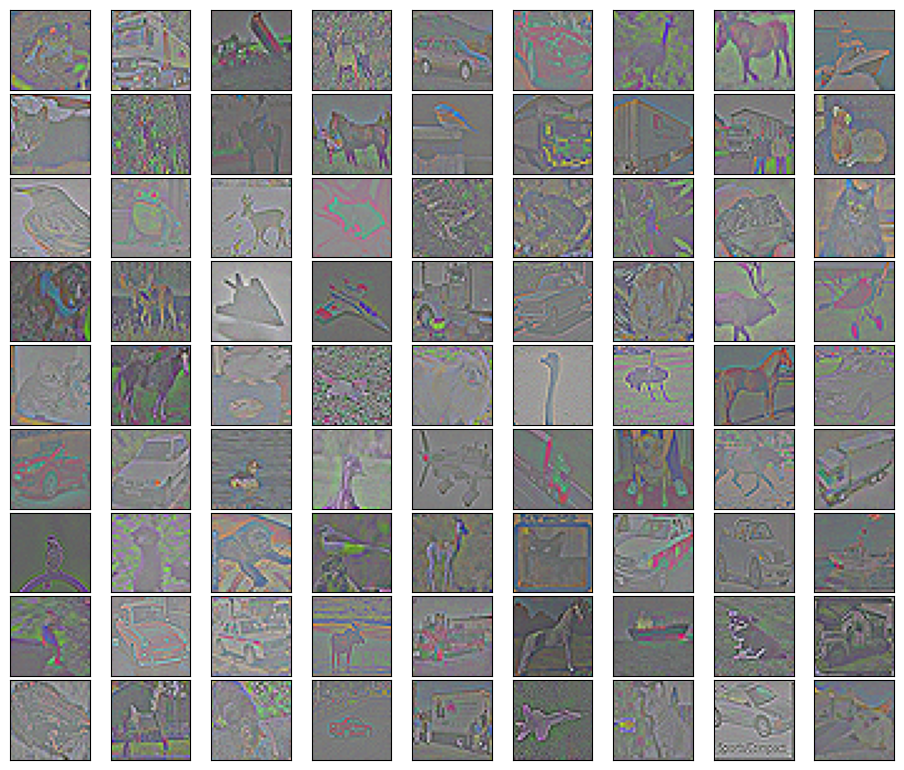

In [8]:
transform_zca = transforms.Compose([transforms.ToTensor(),
                                    zca])

dataloader_train_zca = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data/cifar10', train=True, transform=transform_zca),
    batch_size=batch_size,
    shuffle=False
)

fig = plt.figure(figsize=(9, 15))
fig.subplots_adjust(left=0, right=1, bottom=0, top=0.5, hspace=0.05,
                    wspace=0.05)

i = 0
for x, _ in dataloader_train_zca:
    x = np.transpose(torch.squeeze(x).numpy(), (1, 2, 0))
    ax = fig.add_subplot(9, 9, i + 1, xticks=[], yticks=[])
    ax.imshow(deprocess(x))
    i += 1
    if i >= 81:
        break

## 3.Batch Normalization

- 1ミニバッチ内の全データの同一チャネルをそれぞれ正規化する方法です．
- 深層学習において表現力の高さを保ちつつ，学習の収束の高速化と安定化に寄与します．

![](https://standardfrancis.files.wordpress.com/2015/04/screenshot-from-2015-04-16-133436.png?w=1008)

（図の出典: http://proceedings.mlr.press/v37/ioffe15.html ）

---
- This is a method to normalize each of the same channels of all data within one mini-batch.
- Contributes to faster and more stable convergence of learning while maintaining high expressiveness in deep learning.

![](https://standardfrancis.files.wordpress.com/2015/04/screenshot-from-2015-04-16-133436.png?w=1008)

(Figure source: http://proceedings.mlr.press/v37/ioffe15.html )


In [9]:
class BatchNorm(nn.Module):
    def __init__(self, shape, epsilon=np.float32(1e-5)):
        super().__init__()
        self.gamma = nn.Parameter(torch.tensor(np.ones(shape, dtype='float32')))
        self.beta = nn.Parameter(torch.tensor(np.zeros(shape, dtype='float32')))
        self.epsilon = epsilon

    def forward(self, x):
        mean = torch.mean(x, (0, 2, 3), keepdim=True)   # WRITE ME # You can calculate the average with torch.mean. In addition, for image data, calculations are made for each channel.
        std = torch.std(x, (0, 2, 3), keepdim=True)   # WRITE ME # Standard deviation can be calculated with torch.std
        x_normalized = (x - mean) / (std**2 + self.epsilon)**0.5 # WRITE ME
        return self.gamma * x_normalized + self.beta # WRITE ME

## 4.Dropout

- 過学習を抑制する方法のひとつです．
- Dropoutは特定のレイヤーの出力を学習時にある確率`dropout_ratio`でシャットアウト(0に落とす)ことで，一部のデータが欠損していても正しく認識ができるようにします．
- これにより，画像の一部の局所特徴が過剰に評価されてしまうのを防ぎ，モデルのロバストさを向上させることができます．
- 推論時はすべてのニューロンを使います．そのため，学習時は `1 - dropout_ratio` の割合のニューロンしか使っていないのに，推論時はすべてのニューロンを使ったことによって出力が大きくなってしまうので，出力値に`1 - dropout_ratio`を乗算し，出力の大きさが学習時と同程度になるように調整します．

---
- This is one way to suppress overfitting.
- Dropout shuts out (drops to 0) the output of a specific layer with a certain probability `dropout_ratio` during learning so that it can be recognized correctly even if some data is missing.
- This can prevent some local features of the image from being overestimated and improve the robustness of the model.
- All neurons are used during inference. Therefore, during training, only neurons with a ratio of `1 - dropout_ratio` are used, but during inference, the output becomes large because all neurons are used, so the output value is multiplied by `1 - dropout_ratio` and adjusted so that the size of the output is about the same as during learning.


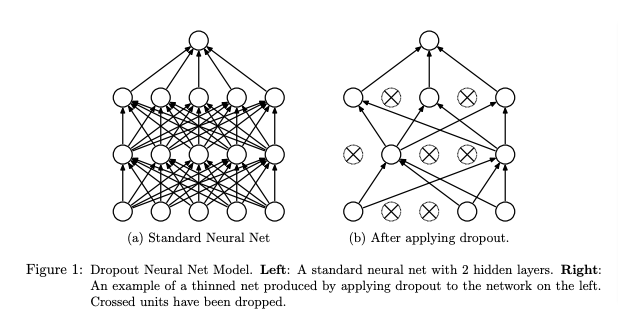


（図の出典（Figure source）：http://jmlr.org/papers/v15/srivastava14a.html
 ）

In [10]:
class Dropout(nn.Module):
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        super().__init__()
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x):
        # Shuts down output by dropout_ratio during learning
        if self.training:
            self.mask = torch.rand(*x.size()) > self.dropout_ratio
            return x * self.mask.to(x.device)
        # During inference, multiply the output by `1.0 - self.dropout_ratio` to match the size of the output during training.
        else:
            return x * (1.0 - self.dropout_ratio)

## 5.畳み込みニューラルネットワーク(Convolutional Neural Networks)の実装と学習

---
## 5. Implementation and learning of Convolutional Neural Networks


### 5.1. 各層クラスの実装

---
### 5.1. Implementation of each layer class


**畳み込み層**

---
**Convolution layer**


In [11]:
class Conv(nn.Module):
    def __init__(self, filter_shape, function=lambda x: x, stride=(1, 1), padding=0):
        super().__init__()
        # Initializing He
        # filter_shape: (Number of output channels) x (Number of input channels) x (Number of vertical dimensions) x (Number of horizontal dimensions)
        fan_in = filter_shape[1] * filter_shape[2] * filter_shape[3]
        fan_out = filter_shape[0] * filter_shape[2] * filter_shape[3]

        self.W = nn.Parameter(torch.tensor(rng.normal(
                        0,
                        np.sqrt(2/fan_in),
                        size=filter_shape
                    ).astype('float32')))

        # Since the bias is for each filter, the number of dimensions is the same as the number of output filters.
        self.b = nn.Parameter(torch.tensor(np.zeros((filter_shape[0]), dtype='float32')))

        self.function = function  # activation function
        self.stride = stride  # stride width
        self.padding = padding  # padding

    def forward(self, x):
        u = F.conv2d(x, self.W, bias=self.b, stride=self.stride, padding=self.padding)
        return self.function(u)

**プーリング層**

---
**Pooling layer**


In [12]:
class Pooling(nn.Module):
    def __init__(self, ksize=(2, 2), stride=(2, 2), padding=0):
        super().__init__()
        self.ksize = ksize  # kernel size
        self.stride = stride  # stride width
        self.padding = padding  # padding

    def forward(self, x):
        return F.avg_pool2d(x, kernel_size=self.ksize, stride=self.stride, padding=self.padding)

**平滑化層（4次元->2次元）**

---
**Smoothing layer (4D->2D)**


In [13]:
class Flatten(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x.view(x.size()[0], -1)

**全結合層**

---
**Fully connected layer**


In [14]:
class Dense(nn.Module):
    def __init__(self, in_dim, out_dim, function=lambda x: x):
        super().__init__()
        # Initializing He
        # in_dim: number of input dimensions, out_dim: number of output dimensions

        self.W = nn.Parameter(torch.tensor(rng.normal(
                        0,
                        np.sqrt(2/in_dim),
                        size=(in_dim, out_dim)
                    ).astype('float32')))

        self.b = nn.Parameter(torch.tensor(np.zeros([out_dim]).astype('float32')))
        self.function = function

    def forward(self, x):
        return self.function(torch.matmul(x, self.W) + self.b)

**活性化層**

---
**Activation layer**


In [15]:
class Activation(nn.Module):
    def __init__(self, function=lambda x: x):
        super().__init__()
        self.function = function

    def __call__(self, x):
        return self.function(x)

### 5.2. ネットワークの構築&データローダーの定義

---
### 5.2. Network construction & data loader definition


**ネットワークの構築**

これまで定義してきた各層クラスを使用して，`conv_net`という変数に3層の畳み込み層をもつニューラル ネットワーク (ConvNet) を定義します．

---
**Building a network**

Using each layer class defined so far, define a neural network (ConvNet) with three convolutional layers in a variable called `conv_net`.


In [16]:
# Prevent nan due to torch.log(0)
def torch_log(x):
    return torch.log(torch.clamp(x, min=1e-10))

In [17]:
# Defining the network
# The width and height of the feature map are ((H - f + 2p) / s ) + 1
# H: Input image width or height f: Filter size (width or height) p: Padding size s: Stride width
conv_net = nn.Sequential(
    Conv((32, 3, 3, 3)),          # WRITE ME # Image size: 32x32x3 -> 30x30x32
    BatchNorm((32, 30, 30)),
    Activation(F.relu),
    Pooling((2, 2)),              # WRITE ME # 30x30x32 -> 15x15x32
    Conv((64, 32, 3, 3)),         # WRITE ME # 15x15x32 -> 13x13x64
    BatchNorm((64, 13, 13)),
    Activation(F.relu),
    Pooling((2, 2)),              # WRITE ME # 13x13x64 -> 6x6x64
    Conv((128, 64, 3, 3)),        # WRITE ME # 6x6x64 -> 4x4x128
    BatchNorm((128, 4, 4)),
    Activation(F.relu),
    Pooling((2, 2)),              # WRITE ME # 4x4x128 -> 2x2x128
    Flatten(),
    Dense(2*2*128, 256, F.relu),  # WRITE ME # Input is the flattened output of the convolutional layer
    Dense(256, 10)
)


batch_size = 100
n_epochs = 10
lr = 0.01
device = 'cuda'

conv_net.to(device)
optimizer = optim.Adam(conv_net.parameters(), lr=lr)

**データローダーの定義**

CIFAR-10の画像をダウンロードし，train用，valid用にデータをランダムに分割します．

---
**Data loader definition**

Download the CIFAR-10 image and randomly divide the data into train and valid.


In [18]:
trainval_dataset = datasets.CIFAR10('./data/cifar10', train=True, transform=transforms.ToTensor())

# define zca
zca = ZCAWhitening()
zca.fit(trainval_dataset)

# Define preprocessing
transform = transforms.Compose([transforms.ToTensor(),
                                zca])

trainval_dataset = datasets.CIFAR10('./data/cifar10', train=True, transform=transform)

# Split into train and valid
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [len(trainval_dataset)-10000, 10000])

dataloader_train = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

dataloader_valid = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train data number:{}, Valid data number: {}".format(len(train_dataset), len(val_dataset)))

0/50000
10000/50000
20000/50000
30000/50000
40000/50000
completed!
Train data number:40000, Valid data number: 10000


### 5.3. 学習

---
### 5.3. Learning


In [19]:
for epoch in range(n_epochs):
    losses_train = []  # List to store training errors
    losses_valid = []  # List to store errors in verification data

    conv_net.train()  # put into training mode
    n_train = 0  # Number of training data
    acc_train = 0  # Accuracy on training data
    for x, t in dataloader_train:
        n_train += t.size()[0]

        conv_net.zero_grad()  # Gradient initialization

        x = x.to(device)  # Move tensor to GPU

        t_hot = torch.eye(10)[t]  # Convert the correct answer label into a one-hot vector

        t = t.to(device)
        t_hot = t_hot.to(device)  # Move the ground truth label and one-hot vector to the GPU

        y = conv_net.forward(x)  # Forward propagation

        loss = -(t_hot*torch.log_softmax(y, dim=-1)).sum(axis=1).mean()  # Calculation of error (cross entropy error function)

        loss.backward()  # Backpropagation of errors

        optimizer.step()  # Update parameters

        pred = y.argmax(1)  # Set the label that takes the maximum value as the predicted label

        acc_train += (pred == t).float().sum().item()
        losses_train.append(loss.tolist())

    conv_net.eval()  # Go to evaluation mode
    n_val = 0
    acc_val = 0
    for x, t in dataloader_valid:
        n_val += t.size()[0]

        x = x.to(device)  # Move tensor to GPU

        t_hot = torch.eye(10)[t]  # Convert the correct answer label into a one-hot vector

        t = t.to(device)
        t_hot = t_hot.to(device)  # Move the ground truth label and one-hot vector to the GPU

        y = conv_net.forward(x)  # Forward propagation

        loss = -(t_hot*torch.log_softmax(y, dim=-1)).sum(axis=1).mean()  # Calculation of error (cross entropy error function)

        pred = y.argmax(1)  # Set the label that takes the maximum value as the predicted label

        acc_val += (pred == t).float().sum().item()
        losses_valid.append(loss.tolist())

    print('EPOCH: {}, Train [Loss: {:.3f}, Accuracy: {:.3f}], Valid [Loss: {:.3f}, Accuracy: {:.3f}]'.format(
        epoch,
        np.mean(losses_train),
        acc_train/n_train,
        np.mean(losses_valid),
        acc_val/n_val
    ))

EPOCH: 0, Train [Loss: 1.360, Accuracy: 0.518], Valid [Loss: 1.081, Accuracy: 0.620]
EPOCH: 1, Train [Loss: 0.858, Accuracy: 0.699], Valid [Loss: 0.822, Accuracy: 0.711]
EPOCH: 2, Train [Loss: 0.681, Accuracy: 0.763], Valid [Loss: 0.758, Accuracy: 0.737]
EPOCH: 3, Train [Loss: 0.567, Accuracy: 0.802], Valid [Loss: 0.730, Accuracy: 0.751]
EPOCH: 4, Train [Loss: 0.495, Accuracy: 0.827], Valid [Loss: 0.731, Accuracy: 0.756]
EPOCH: 5, Train [Loss: 0.414, Accuracy: 0.855], Valid [Loss: 0.777, Accuracy: 0.750]
EPOCH: 6, Train [Loss: 0.354, Accuracy: 0.874], Valid [Loss: 0.801, Accuracy: 0.754]
EPOCH: 7, Train [Loss: 0.309, Accuracy: 0.891], Valid [Loss: 0.870, Accuracy: 0.749]
EPOCH: 8, Train [Loss: 0.265, Accuracy: 0.907], Valid [Loss: 1.043, Accuracy: 0.731]
EPOCH: 9, Train [Loss: 0.245, Accuracy: 0.914], Valid [Loss: 0.961, Accuracy: 0.747]


## 6.Activationの可視化

---
## 6.Activation visualization


各畳み込み層の特徴マップを可視化します．

---
Visualize the feature map of each convolutional layer.


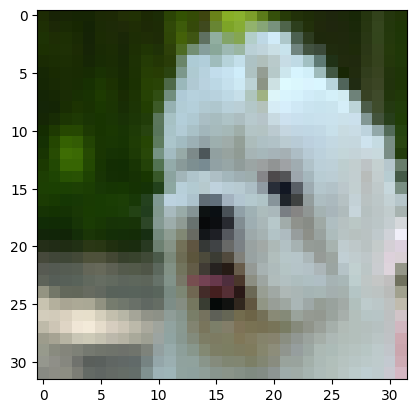

In [20]:
trainval = datasets.CIFAR10('./data/cifar10')
image_id = 919  # Select image to display
sample_image = trainval[image_id][0]
plt.imshow(sample_image)

In [21]:
def feature_map(image, output_layer):  # output_layer function that outputs the feature map of the th layer
    """
    Argumnets
    ---------
    image : torch.Tensor
        input image．(C, H, W)
    output_layer : int
        The layer number that outputs the feature map you want to display．

    Return
    ------
    image : torch.Tensor
        Feature map output from the layer specified by the argument．
    """
    image = transform(image)
    image = conv_net[0:output_layer + 1](image.unsqueeze(0).to(device))
    return image


print("Network structure")
print(conv_net)

Network structure
Sequential(
  (0): Conv()
  (1): BatchNorm()
  (2): Activation()
  (3): Pooling()
  (4): Conv()
  (5): BatchNorm()
  (6): Activation()
  (7): Pooling()
  (8): Conv()
  (9): BatchNorm()
  (10): Activation()
  (11): Pooling()
  (12): Flatten()
  (13): Dense()
  (14): Dense()
)


### 6.1. conv1

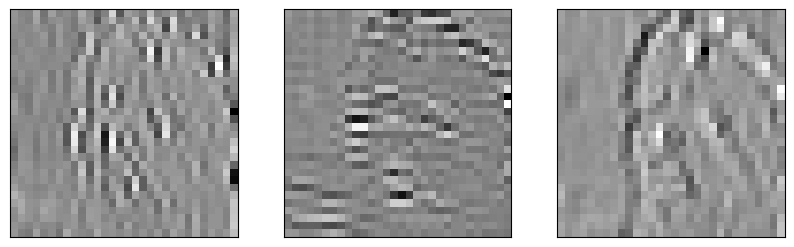

In [22]:
_output = feature_map(sample_image, 0).to("cpu")
fig = plt.figure(figsize=(10, 10))
_output = np.transpose(torch.squeeze(_output).detach().numpy(), (1, 2, 0))
for i in range(3):
    ax = fig.add_subplot(1, 3, i+1, xticks=[], yticks=[])
    ax.imshow(deprocess(_output[:, :, i]), cmap='gray')

### 6.2. conv2


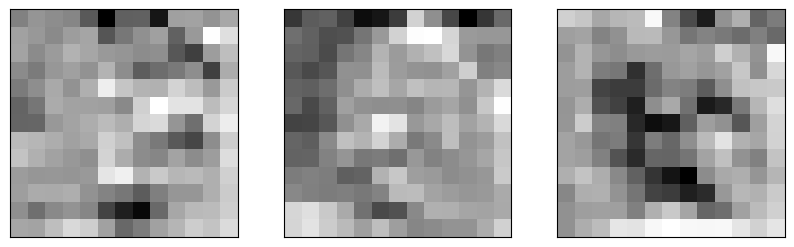

In [23]:
_output = feature_map(sample_image, 4).to("cpu")
fig = plt.figure(figsize=(10, 10))
_output = np.transpose(torch.squeeze(_output).detach().numpy(), (1, 2, 0))
for i in range(3):
    ax = fig.add_subplot(1, 3, i+1, xticks=[], yticks=[])
    ax.imshow(deprocess(_output[:, :, i]), cmap='gray')

### 6.3. conv3


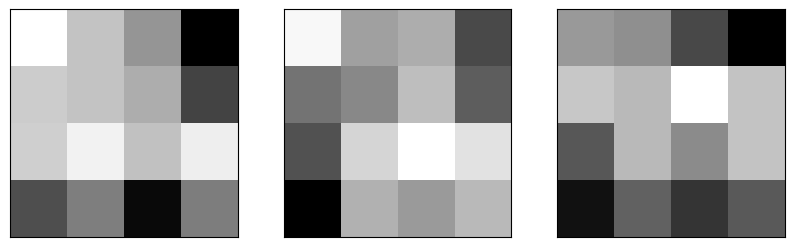

In [24]:
_output = feature_map(sample_image, 8).to("cpu")
fig = plt.figure(figsize=(10, 10))
_output = np.transpose(torch.squeeze(_output).detach().numpy(), (1, 2, 0))
for i in range(3):
    ax = fig.add_subplot(1, 3, i+1, xticks=[], yticks=[])
    ax.imshow(deprocess(_output[:, :, i]), cmap='gray')

学習後の特徴マップの性質として，浅い層はエッジなどの簡単な表現，深い層になるほど複雑な表現を獲得することが知られています．

参考: https://www.iro.umontreal.ca/~bengioy/talks/DL-Tutorial-NIPS2015.pdf (p.34)




---
It is known that the characteristics of the feature map after learning are that shallow layers acquire simple representations such as edges, and deeper layers acquire more complex representations.

Reference: https://www.iro.umontreal.ca/~bengioy/talks/DL-Tutorial-NIPS2015.pdf (p.34)




## 7.torch.nn に含まれるlayer, Loss関数の利用

---
## 7.Using layer and Loss functions included in torch.nn


これまで扱ってきたPytorchの実装では比較的低レベルなAPIを使用してきました．それは本講義ではアルゴリズムの実装にフォーカスするためです．

しかしながら，実際にビジネスや研究で利用するときにはプリミティブな実装を一から書くのは手間になる場合もあります．そのような課題を解決するニーズに答え，Pytorchには高レベルなAPIも用意されています．その一つとして`torch.nn`に含まれるlayerやLoss関数があります．

ここまでは`torch.nn.Module`クラスを継承して様々なlayerを定義してきましたが，実は`torch.nn`に主要なlayer, Loss関数は含まれています．

ここでは，`torch.nn`に含まれるlayer, Loss関数を使って，課題5の畳み込みニューラルネットワークの実装を行ってみましょう．


なお，このような高レベルなAPIは簡単に実装できる反面，実装の柔軟性が落ちるという欠点もあります．場合によって使い分ける必要があります．

`torch.nn`で使えるモジュールは以下のページで確認できます．

[Module: torch.nn](https://pytorch.org/docs/stable/nn.html)

---
The Pytorch implementations we have covered so far have used relatively low-level APIs. This is because this lecture will focus on the implementation of the algorithm.

However, when actually using it for business or research, writing a primitive implementation from scratch may be a hassle. In response to the need to solve such problems, Pytorch also provides a high-level API. One of them is the layer and Loss functions included in `torch.nn`.

So far, we have defined various layers by inheriting the `torch.nn.Module` class, but `torch.nn` actually contains the main layers and Loss functions.

Here, let's implement the convolutional neural network for Task 5 using the layer and Loss functions included in `torch.nn`.


Although such high-level APIs are easy to implement, they also have the disadvantage of reduced implementation flexibility. It is necessary to use them depending on the case.

You can check the modules that can be used with `torch.nn` on the following page.

[Module: torch.nn](https://pytorch.org/docs/stable/nn.html)


一般的なレイヤーは一通り揃っています．

---
All common layers are available.


```python
# 線形層
nn.Linear(input_dim, output_dim)

# 畳み込み層
nn.Conv2d(input_dim, output_dim, kernel_size)

# LSTM（詳細は第7回）
nn.LSTM(input_dim, hidden_dim, num_layers)

...
```

---
```python
# linear layer
nn.Linear(input_dim, output_dim)

# Convolution layer
nn.Conv2d(input_dim, output_dim, kernel_size)

# LSTM (Details in Part 7)
nn.LSTM(input_dim, hidden_dim, num_layers)

...
```


一般的な誤差関数も一通り揃っています．

---
A complete set of general error functions is also available.


```python
# L1誤差
nn.L1Loss()

# 平均二乗誤差
nn.MSELoss()

# 交差エントロピー誤差
nn.CrossEntropyLoss()

...
```

---
```python
# L1 error
nn.L1Loss()

# mean square error
nn.MSELoss()

# Cross entropy error
nn.CrossEntropyLoss()

...
```


### 7.1. ネットワークの構築&データローダーの定義

**ネットワークの構築**

---
### 7.1. Build network & define data loader

**Building a network**


In [25]:
conv_net2 = nn.Sequential(
    nn.Conv2d(3, 32, 3),              # 32x32x3 -> 30x30x32
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.AvgPool2d(2),                  # 30x30x32 -> 15x15x32
    nn.Conv2d(32, 64, 3),             # 15x15x32 -> 13x13x64
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.AvgPool2d(2),                  # 13x13x64 -> 6x6x64
    nn.Conv2d(64, 128, 3),            # 6x6x64 -> 4x4x128
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.AvgPool2d(2),                  # 4x4x128 -> 2x2x128
    nn.Flatten(),
    nn.Linear(2*2*128, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)


def init_weights(m):  # Initializing He
    if type(m) == nn.Linear or type(m) == nn.Conv2d:
        torch.nn.init.kaiming_normal_(m.weight)
        m.bias.data.fill_(0.0)


conv_net2.apply(init_weights)

batch_size = 100
n_epochs = 5
lr = 0.01
device = 'cuda'

conv_net2.to(device)
optimizer2 = optim.Adam(conv_net2.parameters(), lr=lr)
loss_function = nn.CrossEntropyLoss()  # nn.ClossEntropyLoss has the functions of softmax conversion of the output and one-hot vectorization of the correct answer label.

**データローダーの定義**

---
**Data loader definition**


In [26]:
trainval_dataset = datasets.CIFAR10('./data/cifar10', train=True, transform=transforms.ToTensor())

# define zca
zca = ZCAWhitening()
zca.fit(trainval_dataset)

# Define preprocessing
transform = transforms.Compose([transforms.ToTensor(),
                                zca])

trainval_dataset = datasets.CIFAR10('./data/cifar10', train=True, transform=transform)

# Split into train and valid
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [len(trainval_dataset)-10000, 10000])

dataloader_train = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

dataloader_valid = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True
)

0/50000
10000/50000
20000/50000
30000/50000
40000/50000
completed!


### 7.2. 学習

---
### 7.2. Learning


In [27]:
for epoch in range(n_epochs):
    losses_train = []
    losses_valid = []

    conv_net2.train()
    n_train = 0
    acc_train = 0
    for x, t in dataloader_train:
        n_train += t.size()[0]

        conv_net2.zero_grad()  # Gradient initialization

        x = x.to(device)  # Move tensor to GPU
        t = t.to(device)

        y = conv_net2.forward(x)  # Forward propagation

        loss = loss_function(y, t)  # Calculation of error (cross entropy error function)

        loss.backward()  # Backpropagation of errors

        optimizer2.step()  # Update parameters

        pred = y.argmax(1)  # Set the label that takes the maximum value as the predicted label

        acc_train += (pred == t).float().sum().item()
        losses_train.append(loss.tolist())

    conv_net2.eval()
    n_val = 0
    acc_val = 0
    for x, t in dataloader_valid:
        n_val += t.size()[0]

        x = x.to(device)  # Move tensor to GPU
        t = t.to(device)

        y = conv_net2.forward(x)  # Forward propagation

        loss = loss_function(y, t)  # Calculation of error (cross entropy error function)

        pred = y.argmax(1)  # Set the label that takes the maximum value as the predicted label

        acc_val += (pred == t).float().sum().item()
        losses_valid.append(loss.tolist())

    print('EPOCH: {}, Train [Loss: {:.3f}, Accuracy: {:.3f}], Valid [Loss: {:.3f}, Accuracy: {:.3f}]'.format(
        epoch,
        np.mean(losses_train),
        acc_train/n_train,
        np.mean(losses_valid),
        acc_val/n_val
    ))

EPOCH: 0, Train [Loss: 1.430, Accuracy: 0.497], Valid [Loss: 1.007, Accuracy: 0.648]
EPOCH: 1, Train [Loss: 0.874, Accuracy: 0.695], Valid [Loss: 1.117, Accuracy: 0.642]
EPOCH: 2, Train [Loss: 0.700, Accuracy: 0.757], Valid [Loss: 0.796, Accuracy: 0.730]
EPOCH: 3, Train [Loss: 0.597, Accuracy: 0.793], Valid [Loss: 0.773, Accuracy: 0.736]
EPOCH: 4, Train [Loss: 0.520, Accuracy: 0.819], Valid [Loss: 0.719, Accuracy: 0.762]
